# Asian vs African Elephant Image Classification

Use `ImageDataGenerator`

```python
form keras.preprocessing.image import ImageDataGenerator

In [15]:
import warnings
warnings.filterwarnings('ignore')

In [16]:
import keras
from keras import layers, models, Sequential, regularizers
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D

### Loading the dataset and splitting it into training and validation

In [17]:
base_dir = "/kaggle/input/datasets/vivmankar/asian-vs-african-elephant-image-classification/dataset/train"

train_ds = keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    seed=42,
    image_size=(256,256),
    batch_size=32,
    label_mode='int',
    color_mode='rgb',
    shuffle=True,
    subset='training',
    crop_to_aspect_ratio=True,
    pad_to_aspect_ratio=False    
)
val_ds = keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    seed=42,
    image_size=(256,256),
    batch_size=32,
    label_mode='int',
    color_mode='rgb',
    shuffle=True,
    subset='validation',
    crop_to_aspect_ratio=True,
    pad_to_aspect_ratio=False    
)

Found 840 files belonging to 2 classes.
Using 672 files for training.
Found 840 files belonging to 2 classes.
Using 168 files for validation.


* **directory**: The file path to the folder containing your dataset subfolders (each folder representing a class).
* **labels='inferred'**: Keras automatically generates labels (0, 1, 2...) based on the names of the subfolders found in the directory.
* **label_mode='int'**: Encodes labels as integers. Use 'categorical' for one-hot encoding or 'binary' for two-class tasks.
* **class_names=None**: By default, Keras infers all subfolders. You can provide a list of specific subfolder names here if you only want to load a subset of your data.
* **color_mode='rgb'**: Determines the number of channels. 'rgb' (3 channels) is default; use 'grayscale' (1 channel) for black and white images.
* **batch_size=32**: The number of images loaded into memory at once during each training step. 32 is the industry standard.
* **image_size=(256, 256)**: Resizes every input image to these dimensions. This is mandatory because neural networks require all input tensors to have the same shape. 
* **shuffle=True**: Randomizes the order of images every epoch. This is vital to ensure the model does not learn the sequence of the data.
* **seed=None**: Set this to a specific number (e.g., seed=42) if you want the shuffling to be the same every time you run your code.
* **validation_split=None**: The fraction of data (e.g., 0.2) to reserve for validation. Requires you to also set the subset parameter.
* **subset=None**: Specify 'training' or 'validation' when using a validation_split.
* **interpolation='bilinear'**: The mathematical method used to resize images. Bilinear is standard; use nearest or bicubic for specialized requirements.
* **follow_links=False**: Set to True if your directories contain symbolic links to images located elsewhere on your computer.
* **crop_to_aspect_ratio=False**: If True, Keras will crop the image to maintain its original aspect ratio instead of stretching it. 
* **pad_to_aspect_ratio=False**: If True, Keras adds padding (empty pixels) to make the image square rather than stretching it.
* **data_format=None**: Usually left as None (defaults to 'channels_last'). It determines whether the color channel index is the first or last dimension of the tensor.
* **format='tf'**: Specifies the return format. 'tf' returns a TensorFlow tf.data.Dataset object.
* **verbose=True**: Prints log messages to your console summarizing the number of images and classes found.

In [18]:
print(f"TRAINING DATASET BATCHES : {len(train_ds)}")
print(f"VALIDATION DATASET BATCHES : {len(val_ds)}")

TRAINING DATASET BATCHES : 21
VALIDATION DATASET BATCHES : 6


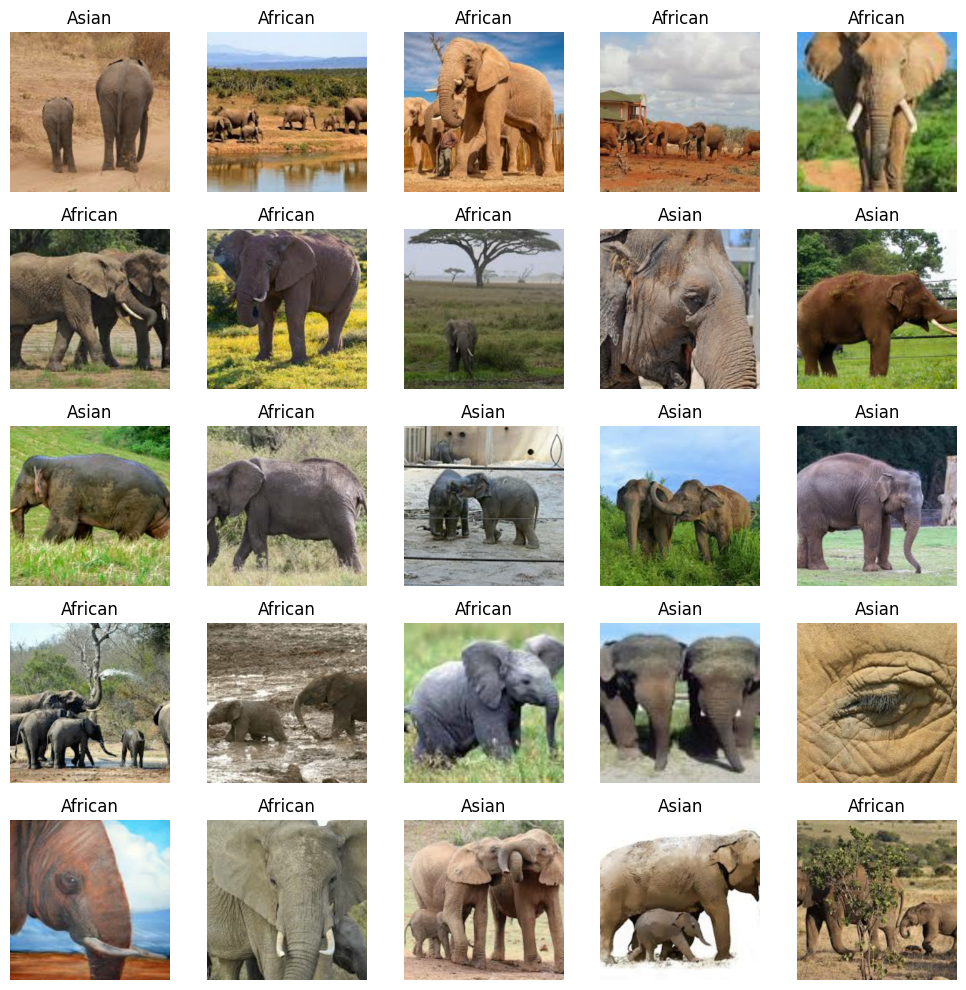

In [19]:
import matplotlib.pyplot as plt

for img_batch, label_batch in train_ds.take(1):
    plt.figure(figsize=(10,10))

    for i in range(25):
        ax = plt.subplot(5, 5, i + 1)        
        plt.imshow(img_batch[i].numpy().astype('uint8'))        
        label_index = label_batch[i].numpy()                       # converting the batches into a numpy array
        plt.title(train_ds.class_names[label_index])        
        plt.axis("off") 

plt.tight_layout()  
plt.show()

In [20]:
train_ds.class_names

['African', 'Asian']

In [21]:
for images, labels in train_ds.take(1):          # getting only one batch
    first_img = images[0]                        # getting only one image (very first img) from images
    first_label = labels[0]                      # getting only one label (very first label) from labels

    print(first_label)
    print(first_img)
    break

tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor(
[[[ 80.        73.        57.      ]
  [ 75.91211   65.99219   52.328125]
  [ 74.83984   62.839844  50.839844]
  ...
  [ 12.759766  17.759766  13.759766]
  [ 10.        15.        11.      ]
  [ 10.        15.        11.      ]]

 [[ 82.91992   75.91992   59.91992 ]
  [ 76.10373   66.86588   53.20182 ]
  [ 71.655304  60.465126  48.465126]
  ...
  [ 12.137001  17.137001  13.137001]
  [ 11.167969  16.167969  12.167969]
  [ 11.167969  16.167969  12.167969]]

 [[ 85.        78.        62.      ]
  [ 82.86595   74.114     60.449932]
  [ 80.16825   69.74303   57.743027]
  ...
  [ 11.648441  16.648441  12.03516 ]
  [ 12.358147  17.358147  12.744865]
  [ 12.        17.        12.386719]]

 ...

 [[155.83984  164.45312  105.146484]
  [155.03003  163.28516  104.15759 ]
  [153.93387  161.93387  102.93387 ]
  ...
  [153.04156  158.04156  100.04157 ]
  [157.83604  162.83604  104.836044]
  [161.38672  166.38672  108.38672 ]]

 [[151.91992  159.91992  10

In [22]:
for a, b in train_ds.take(1):
    print(b[:].numpy())
    print(train_ds.class_names[b[1].numpy()])

[1 1 1 0 1 1 1 1 1 0 0 0 0 0 0 1 0 1 1 1 0 0 1 1 1 0 0 1 0 1 1 0]
Asian


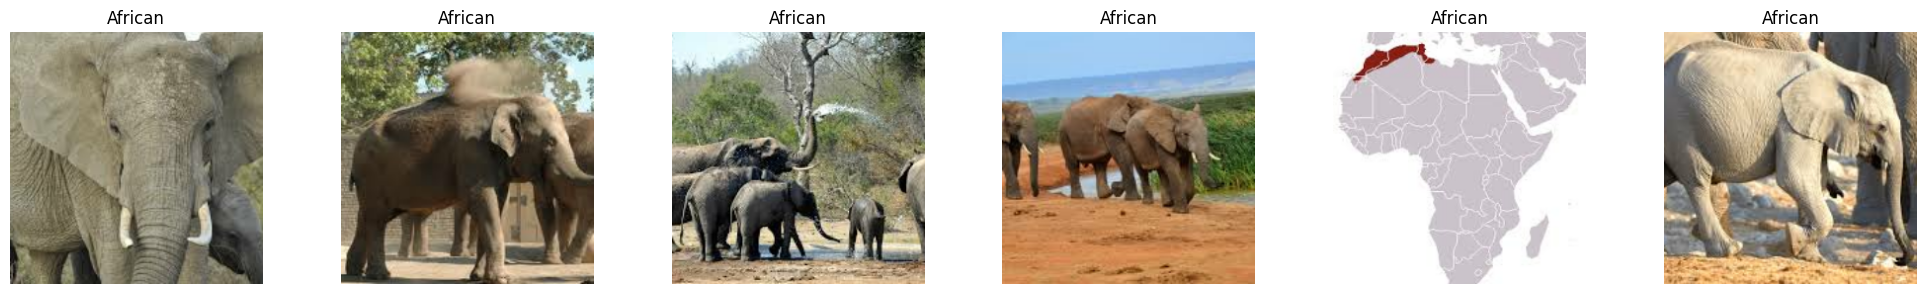

In [23]:
plt.figure(figsize=(20, 3))

for i, (images, labels) in enumerate(train_ds.take(6)):
    plt.subplot(1,6, i+1)
    plt.imshow(images[0].numpy().astype('uint8'))
    label = labels[i].numpy()
    plt.title(train_ds.class_names[label])
    plt.axis('off')
plt.tight_layout()
plt.show()

### Making the Model

In [ ]:
model = Sequential([
    # Data Augmentation
    layers.RandomFlip('horizontal', input_shape=(256,256,3)),
    layers.RandomRotation(0.15),s
    layers.RandomZoom(0.2),
    layers.RandomBrightness(0.2),

    # Resclaing (applying normalization [putting values btwn 0 to 1])
    layers.Rescaling(1./255),

    # Convolutional layers
    layers.Conv2D(32, kernel_size=(3,3), strides=(2,2), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2), strides=1),
    layers.Conv2D(64, kernel_size=(2,2), strides=(2,2), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2), strides=1),
    layers.Conv2D(128, kernel_size=(2,2), strides=(2,2), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2), strides=1),
    

    # Flattening
    layers.Flatten(),

    layers.Dense(68, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.15),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.15),
    layers.Dense(1, activation='sigmoid')
])

In [32]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    epochs = 15,
    validation_data = val_ds
)

Epoch 1/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.5104 - loss: 1.8825 - val_accuracy: 0.5060 - val_loss: 1.4646
Epoch 2/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5045 - loss: 1.3223 - val_accuracy: 0.5298 - val_loss: 1.1984
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5030 - loss: 1.1263 - val_accuracy: 0.5417 - val_loss: 1.0590
Epoch 4/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5298 - loss: 1.0191 - val_accuracy: 0.5238 - val_loss: 0.9758
Epoch 5/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5030 - loss: 0.9383 - val_accuracy: 0.5476 - val_loss: 0.9010
Epoch 6/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.4940 - loss: 0.8753 - val_accuracy: 0.5060 - val_loss: 0.8505
Epoch 7/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.4955 - loss: 0.8330 - val_accuracy: 0.5060 - val_loss: 0.8156
Epoch 8/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.5045 - loss: 0.8036 - val_accuracy: 0.5060 - v

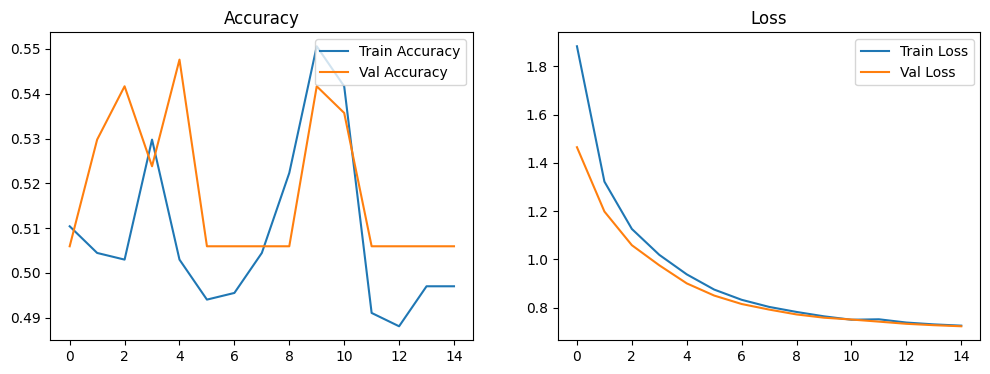

In [33]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()